#### import libraries

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

#### Load the customer segmentation data

In [7]:
customer_data = pd.read_csv('customer_segmentation_data.csv')

In [8]:
print(customer_data)

     CustomerID  Age  Annual Income  Spending Score
0             1   56          47795              43
1             2   69          52709              75
2             3   46          64472              23
3             4   32          34027              55
4             5   60          51630              80
..          ...  ...            ...             ...
295         296   18          47839              15
296         297   65          51920              29
297         298   29          42779               8
298         299   22          32779               5
299         300   54          40966              29

[300 rows x 4 columns]


#### Selecting features for K-means clustering

In [9]:
#The values K-means will use to group customers
features = customer_data[['Age','Annual Income','Spending Score']]

In [10]:
print(features)  #Spending score (how much they spend in a certain period)

     Age  Annual Income  Spending Score
0     56          47795              43
1     69          52709              75
2     46          64472              23
3     32          34027              55
4     60          51630              80
..   ...            ...             ...
295   18          47839              15
296   65          51920              29
297   29          42779               8
298   22          32779               5
299   54          40966              29

[300 rows x 3 columns]


#### Determine the optimal number of clusters using the Elbow method

In [12]:
wcss = [] 
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, n_init=10 random_state=42)
    kmeans.fit(features) 
    wcss.append(kmeans.inertia_)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (625861078.py, line 3)

In [12]:
print(wcss)

[76379600513.16998, 26185365938.451454, 13376869393.183638, 8165999703.744404, 5826576614.468736, 4167483195.423298, 3128725996.374407, 2472705567.3900933, 1864328873.911557, 1531930842.2937005]


#### Plot WCSS vs. Number of Clusters (k):

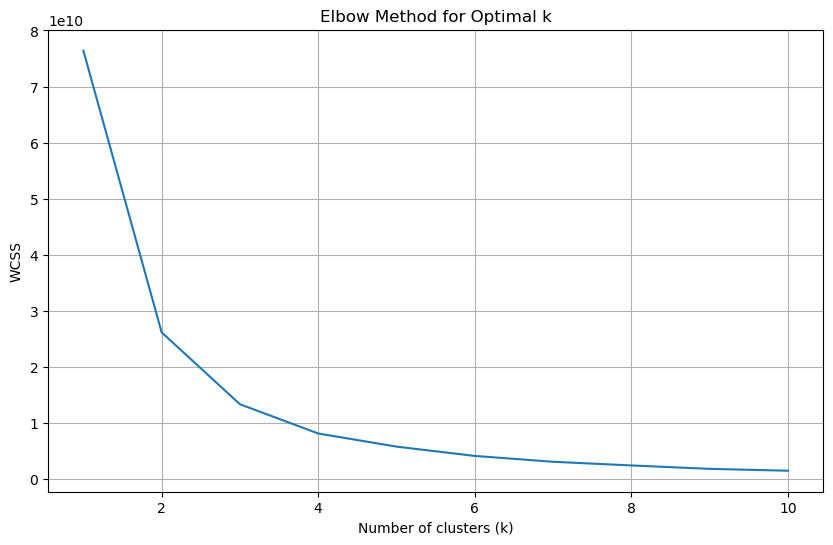

In [14]:
# Plotting the Elbow method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid()
plt.show()

#note: The "elbow" in this plot indicates the optimal number of clusters, where adding more clusters doesn't significantly reduce the WCSS anymore

In [20]:
#Train final K-means with 5 clusters obtained from elbow method
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(features) #Adds a new column "Cluster" in customer data

In [22]:
# Save the updated DataFrame with cluster labels
customer_data.to_csv('customer_segmentation_with_clusters_new.csv', index=False)